In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [4]:
class GradientBoostingRegressorScratch:
    def __init__(self, n_estimators=5, learning_rate=0.1, max_depth=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []
        self.init_pred = None
        self.history = []

    def fit(self, X, y):
        # Step 1: initial prediction (mean)
        self.init_pred = np.mean(y)
        y_pred = np.full_like(y, self.init_pred)

        self.models = []
        self.history = [y_pred.copy()]

        # Step 2: sequential learning
        for _ in range(self.n_estimators):
            # Residuals
            residuals = y - y_pred

            # Train weak learner on residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            # Predict residuals
            update = tree.predict(X)

            # Update predictions
            y_pred += self.learning_rate * update

            # Save model and history
            self.models.append(tree)
            self.history.append(y_pred.copy())

    def predict(self, X):
        y_pred = np.full(X.shape[0], self.init_pred)

        for tree in self.models:
            y_pred += self.learning_rate * tree.predict(X)

        return y_pred


In [5]:
np.random.seed(42)
X = np.linspace(0, 6, 100).reshape(-1, 1)
y = np.sin(X).ravel()

# Add noise
y[::5] += 0.5 * np.random.randn(20)

In [6]:
model = GradientBoostingRegressorScratch(
    n_estimators=5,
    learning_rate=0.3,
    max_depth=2
)
model.fit(X, y)

In [7]:
def plot_steps(X, y, model):
    for i, preds in enumerate(model.history):
        plt.figure()
        plt.scatter(X, y)
        plt.plot(X, preds)
        plt.title(f"Step {i}: Model Prediction")
        plt.xlabel("X")
        plt.ylabel("y")
        plt.show()

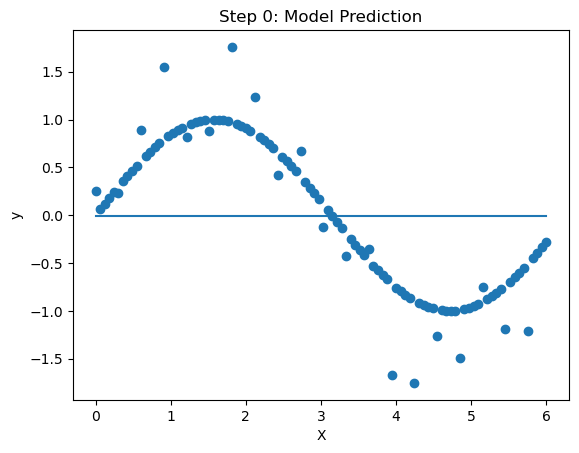

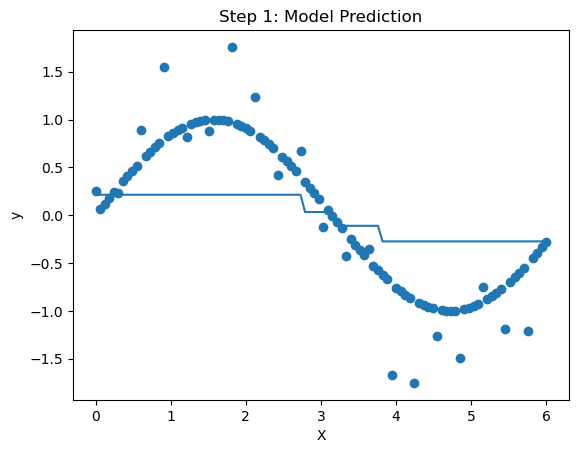

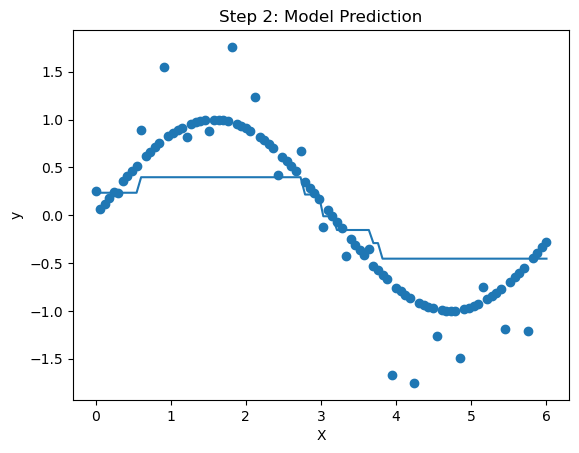

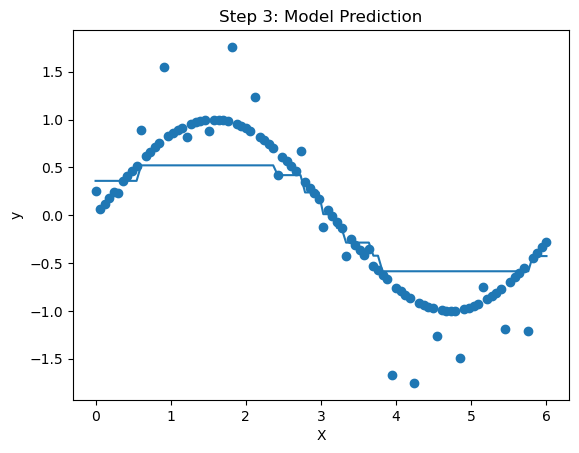

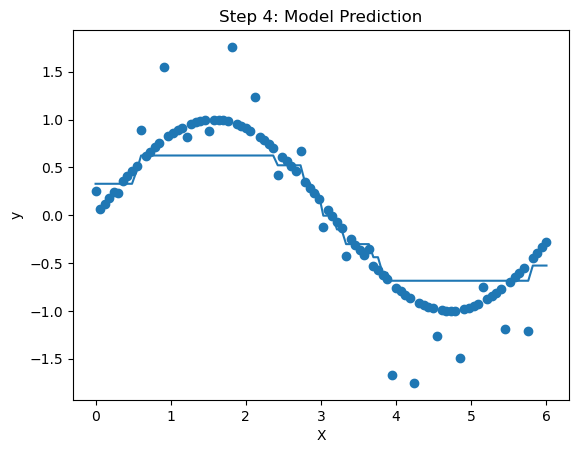

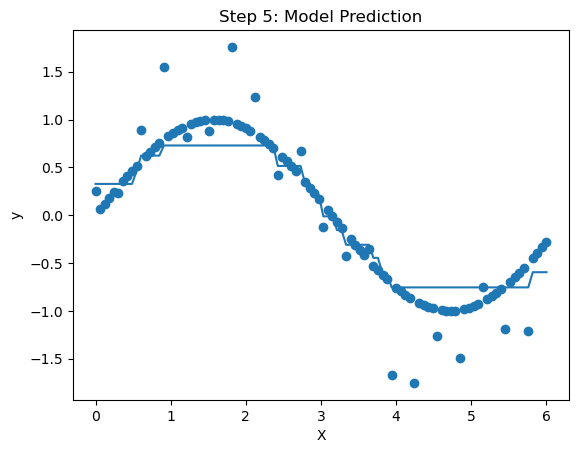

In [8]:
plot_steps(X, y, model)